In [132]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import pandas as pd
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import marineHeatWaves as mhw


data=np.load(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\20230525HeatBudget&HeatWave_try.npz')
data.files
lon=np.array(data['lon'])
lat=np.array(data['lat'])
time=pd.date_range('2020-01-01','2022-12-31',freq='1D')

ssts=np.load(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\25_05_2023_oisstv2r01_NEP.npy')
ssts_solid=np.nanmean(ssts,axis=-1)
t = np.arange(date(1981,9,1).toordinal(),date(2022,12,31).toordinal()+1)
time_mhw=pd.date_range('1981-09-01','2022-12-31',freq='1D')
dataset=nc.Dataset(r'F:\OceanData\OISST_2022\oisst-avhrr-v02r01.20220101.nc')    # type: ignore
lons=np.array(dataset.variables['lon'])
lats=np.array(dataset.variables['lat'])
lon_ind=(lons>=150)&(lons<=250)
lat_ind=(lats>=20)&(lats<=60)
Lon,Lat=np.meshgrid(lons[lon_ind],lats[lat_ind])



def plot_sea_surface_temperature(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date):
    global data
    global lon
    global lat
    global time
    global t
    global time_mhw
    global Lon
    global Lat
    
    lonind=(lon>=left_lon)&(lon<=right_lon)
    latind=(lat>=lower_lat)&(lat<=upper_lat)
    timeind=(time>=pd.to_datetime(start_date))&(time<=pd.to_datetime(end_date))
    # print(lonind.shape,latind.shape,timeind.shape)
    # print(np.array(data['mltt'])[timeind,:,:].shape)
    # print(np.array(data['mltt'])[timeind,:,:][:,latind,:].shape)
    mltt=np.array(data['mltt'])[timeind,:,:][:,latind,:][:,:,lonind]/24
    Q=np.array(data['Q'])[timeind,:,:][:,latind,:][:,:,lonind]
    hadv=np.array(data['hadv'])[timeind,:,:][:,latind,:][:,:,lonind]
    ovmix=mltt-Q-hadv
    y0=np.zeros(shape=[time[timeind].shape[0]])
    y1=np.copy(y0)
    y1[:]=0.2
    y0[:]=-0.2
    plt.figure(figsize=[20,13])

    ax=plt.subplot(3,1,1,projection=ccrs.PlateCarree(central_longitude=180))
    plt.title(f'Mean SST From {start_date} To {end_date}')
    timemhw_ind=(time_mhw>=pd.to_datetime(start_date))&(time_mhw<=pd.to_datetime(end_date))
    
    c=ax.contourf(Lon,Lat,ssts_solid,20,transform=ccrs.PlateCarree(central_longitude=0),cmap='jet')
    plt.colorbar(c,ax=ax,orientation="horizontal",extend='both',shrink=0.4)
    ax.set_xticks(range(150-180, 250-180+1, 15))
    ax.set_yticks(range(20, 60+1, 5))
    ax.set_xlim(150-180, 250-180)
    ax.set_ylim(20, 60)
    import matplotlib.patches as patches
    rect = patches.Rectangle((left_lon-180, lower_lat),right_lon-left_lon, upper_lat-lower_lat, linewidth=2, edgecolor='k', facecolor='none')
    ax.add_patch(rect)# 将矩形添加到ax中
    lon_formatter = LongitudeFormatter(number_format='.0f',
                                        degree_symbol='',
                                        dateline_direction_label=True)
    lat_formatter = LatitudeFormatter(number_format='.0f',
                                        degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    
    scale = '10m'
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', scale, edgecolor='face', facecolor=cfeature.COLORS['land'])
    ax.add_feature(land, facecolor='0.75')
    ax.coastlines()
    
    plt.subplot(3,1,2)
    plt.title('Heat Wave')
    datas=np.load(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\25_05_2023_oisstv2r01_NEP.npy')[latind,:,:][:,lonind,:]
    sst=np.nanmean(np.nanmean(datas,axis=0),axis=0)
    mhws, clim = mhw.detect(t, sst)
    plt.plot(time_mhw,sst,label='sst')
    plt.plot(time_mhw,np.array(clim['seas']),label='clim')
    plt.plot(time_mhw,np.array(clim['thresh']),label='thresh')
    ev = np.argmax(mhws['intensity_max']) # Find largest event
    t1 = np.where(t==mhws['time_start'][0])[0][0]
    t2 = np.where(t==mhws['time_end'][0])[0][0]
    plt.fill_between(time_mhw[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1],color=(1,0.6,0.5),label='MHW')
    plt.legend()
    for ev0 in range(1,mhws['n_events']):
        t1 = np.where(t==mhws['time_start'][ev0])[0][0]
        t2 = np.where(t==mhws['time_end'][ev0])[0][0]
        plt.fill_between(time_mhw[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1],color=(1,0.6,0.5))
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('℃')

    
    
    
    plt.subplot(3,1,3)
    plt.title('Heat Budget')
    plt.plot(time[timeind],np.nanmean(np.nanmean(Q,axis=-1),axis=-1),label='Q')
    plt.plot(time[timeind],np.nanmean(np.nanmean(mltt,axis=-1),axis=-1),label='MLTT')
    plt.plot(time[timeind],np.nanmean(np.nanmean(hadv,axis=-1),axis=-1),label='HADV')
    #pltsea of thieves Ocean.plot(time[:-1],np.nanmean(np.nanmean(ovmix1,axis=-1),axis=-1),label='ENT')
    #plt.plot(time,np.nanmean(np.nanmean(ovmix2,axis=-1),axis=-1),label='MIX')
    plt.plot(time[timeind],np.nanmean(np.nanmean(ovmix,axis=-1),axis=-1),label='OVMIX')
    plt.legend()
    plt.axhline(y=0, color='r', linestyle='--')
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) > 0,
        alpha=0.1,
        color='#840000',
    )
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) < 0,
        alpha=0.1,
        color='#10457e',
    )
    plt.ylim(-0.2,0.2)
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('[℃/Days]')
    plt.xlabel('Time[Days]')
    ax.grid()
    plt.savefig(r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\png.png')
    print(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date)

    # 返回图片路径供Gradio使用
    return r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\png.png'
# plot_sea_surface_temperature(150+60, 250-30, 30, 40, '20210601', '20220901')



# 创建Gradio接口
iface = gr.Interface(
    fn=plot_sea_surface_temperature,
    inputs=[
        gr.inputs.Slider(150, 250, 1, label='左经度 150~250',default=200.),
        gr.inputs.Slider(150, 250, 1, label='右经度 150~250',default=225.),
        gr.inputs.Slider(20, 60, 1, label='下纬度 20~60',default=40.),
        gr.inputs.Slider(20, 60, 1, label='上纬度 20~60',default=50.),
        gr.inputs.Textbox(label="开始时间 2020~2022",default='20210101'),
        gr.inputs.Textbox(label="结束时间 2020~2022",default='20211231')
    ],
    outputs=gr.outputs.Image(type="filepath", label="Developed by Han 25/05/2023"),
    layout="vertical",
    title="NEP HeatWave & HeatBudget"
)
# 启动Gradio应用
iface.launch(server_name="0.0.0.0",server_port=8080,)

C:\Users\XUEX\AppData\Local\Temp\ipykernel_29068\4184782134.py:20: RuntimeWarning: Mean of empty slice
  ssts_solid=np.nanmean(ssts,axis=-1)
c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\gradio\inputs.py:89: UserWarning: Usage of gradio.inputs is deprecated, and will not be supported in the future, please import your component from gradio.components
  warnings.warn(
c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\gradio\inputs.py:93: UserWarning: `optional` parameter is deprecated, and it has no effect
  super().__init__(
c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\gradio\inputs.py:27: UserWarning: Usage of gradio.inputs is deprecated, and will not be supported in the future, please import your component from gradio.components
  warnings.warn(
c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\gradio\inputs.py:30: UserWarning: `optional` parameter is deprecated, and it has no effect
  super().__init__(
c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\gradio\inputs

Running on local URL:  http://0.0.0.0:8080

To create a public link, set `share=True` in `launch()`.


200 225 40 50 20210101 20211231


In [1]:
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import pandas as pd
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import marineHeatWaves as mhw

In [2]:
data=np.load('20230525HeatBudget&HeatWave_2020_2022.npz')
mltt=np.array(data['mltt'])
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])
lon=np.array(data['lon'])[:-1]
lat=np.array(data['lat'])[:-1]
np.savez('20230525HeatBudget&HeatWave_try.npz',mltt=mltt[:,:-1,:-1],Q=Q[:,:-1,:-1],hadv=hadv[:,:,:],lon=lon,lat=lat)
data=np.load('20230525HeatBudget&HeatWave_try.npz')
ssts=np.load('25_05_2023_oisstv2r01_NEP.npy')
data.files

['mltt', 'Q', 'hadv', 'lon', 'lat']

In [3]:
mltt=np.array(data['mltt'])
Q=np.array(data['Q'])
hadv=np.array(data['hadv'])
lon=np.array(data['lon'])
lat=np.array(data['lat'])
time=pd.date_range('2020-01-01','2022-12-31',freq='1D')
t = np.arange(date(1981,9,1).toordinal(),date(2022,12,31).toordinal()+1)
time_mhw=pd.date_range('1981-09-01','2022-12-31',freq='1D')
ssts_solid=np.nanmean(ssts,axis=-1)
dataset=nc.Dataset(r'F:\OceanData\OISST_2022\oisst-avhrr-v02r01.20220101.nc')    # type: ignore
lons=np.array(dataset.variables['lon'])
lats=np.array(dataset.variables['lat'])
lon_ind=(lons>=150)&(lons<=250)
lat_ind=(lats>=20)&(lats<=60)
Lon,Lat=np.meshgrid(lons[lon_ind],lats[lat_ind])

C:\Users\XUEX\AppData\Local\Temp\ipykernel_16896\2767010979.py:9: RuntimeWarning: Mean of empty slice
  ssts_solid=np.nanmean(ssts,axis=-1)


In [11]:
ssta=np.load(r'15052023_SSTA_2020_2023_NEP.npy')

C:\Users\XUEX\AppData\Local\Temp\ipykernel_16896\3560519293.py:30: RuntimeWarning: Mean of empty slice
  ssta_n=np.nanmean(ssta[:,:,timeind],axis=-1)


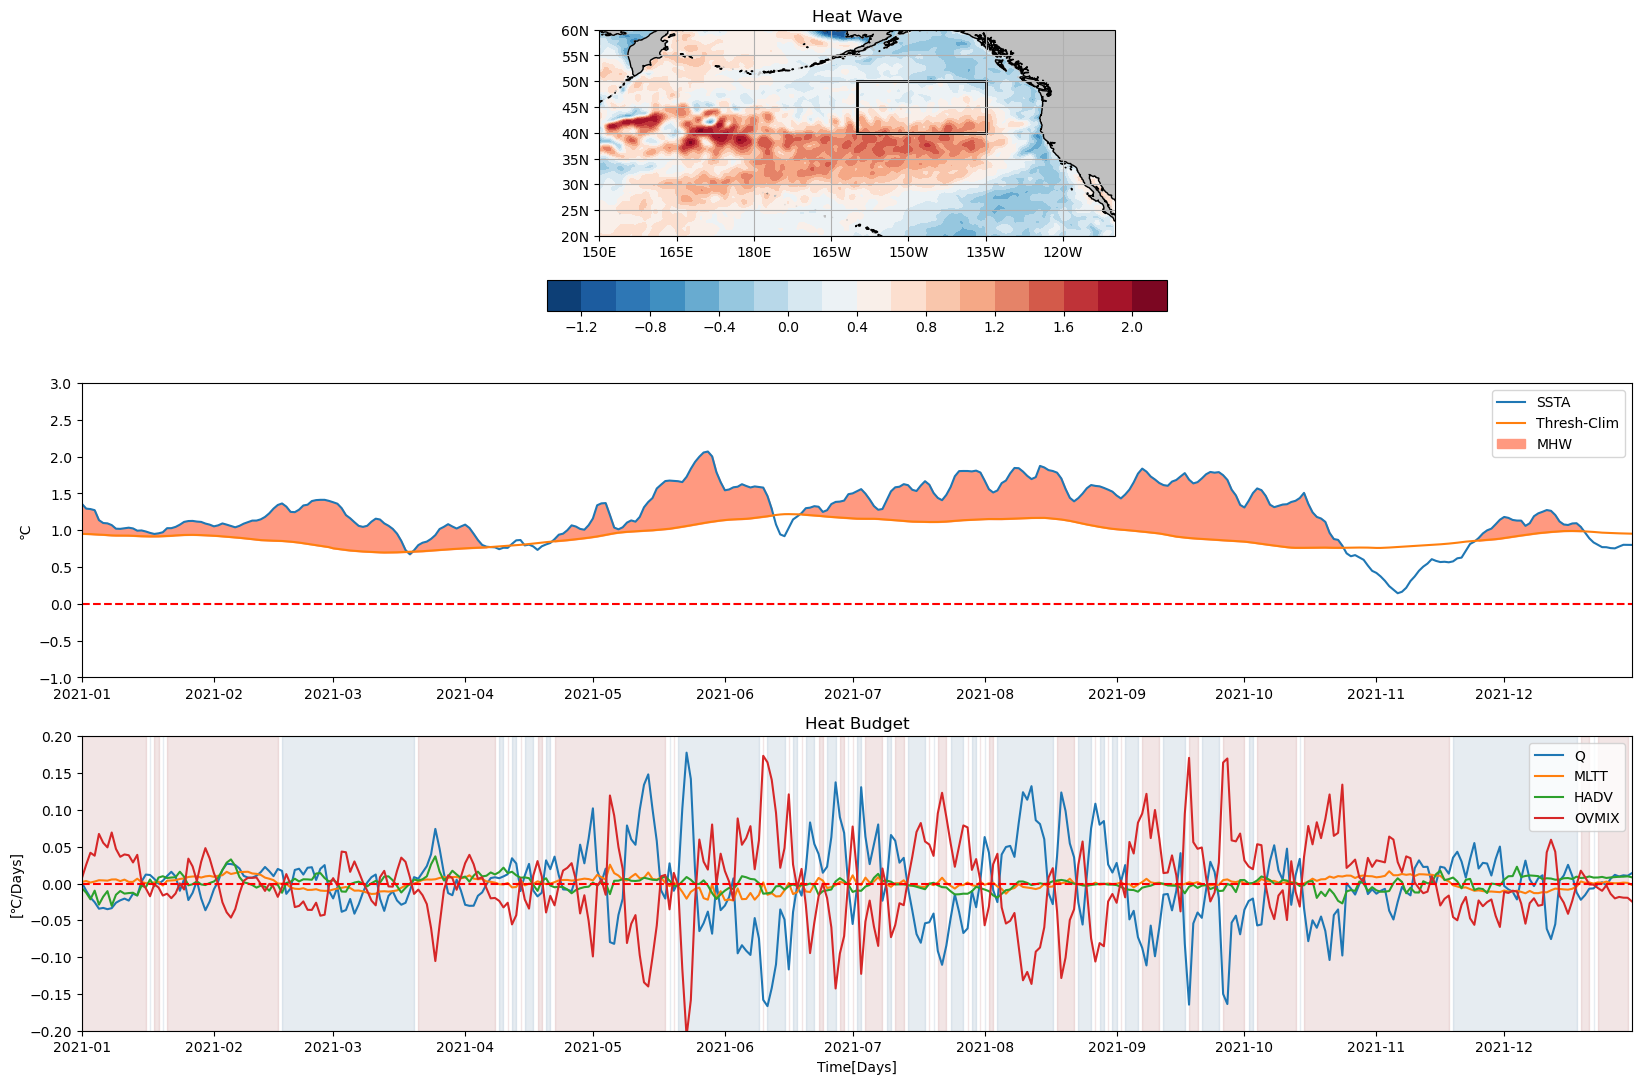

200 225 40 50 20210101 20211231


In [14]:

def plot_sea_surface_temperature(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date):
    global data
    global lon
    global lat
    global time
    global t
    global time_mhw
    global Lon
    global Lat
    
    lonind=(lon>=left_lon)&(lon<=right_lon)
    latind=(lat>=lower_lat)&(lat<=upper_lat)
    timeind=(time>=pd.to_datetime(start_date))&(time<=pd.to_datetime(end_date))
    # print(lonind.shape,latind.shape,timeind.shape)
    # print(np.array(data['mltt'])[timeind,:,:].shape)
    # print(np.array(data['mltt'])[timeind,:,:][:,latind,:].shape)
    mltt=np.array(data['mltt'])[timeind,:,:][:,latind,:][:,:,lonind]/24
    Q=np.array(data['Q'])[timeind,:,:][:,latind,:][:,:,lonind]
    hadv=np.array(data['hadv'])[timeind,:,:][:,latind,:][:,:,lonind]
    ovmix=mltt-Q-hadv
    y0=np.zeros(shape=[time[timeind].shape[0]])
    y1=np.copy(y0)
    y1[:]=0.2
    y0[:]=-0.2
    plt.figure(figsize=[20,13])

    ax=plt.subplot(3,1,1,projection=ccrs.PlateCarree(central_longitude=180))
    plt.title(f'Mean SSTA From {start_date} To {end_date}')
    timemhw_ind=(time_mhw>=pd.to_datetime(start_date))&(time_mhw<=pd.to_datetime(end_date))
    ssta_n=np.nanmean(ssta[:,:,timeind],axis=-1)
    c=ax.contourf(Lon,Lat,ssta_n,20,transform=ccrs.PlateCarree(central_longitude=0),cmap='RdBu_r')
    plt.colorbar(c,ax=ax,orientation="horizontal",extend='both',shrink=0.4)
    plt.title('Heat Wave')
    ax.set_xticks(range(150-180, 250-180+1, 15))
    ax.set_yticks(range(20, 60+1, 5))
    ax.set_xlim(150-180, 250-180)
    ax.set_ylim(20, 60)
    import matplotlib.patches as patches
    rect = patches.Rectangle((left_lon-180, lower_lat),right_lon-left_lon, upper_lat-lower_lat, linewidth=2, edgecolor='k', facecolor='none')
    ax.add_patch(rect)# 将矩形添加到ax中
    lon_formatter = LongitudeFormatter(number_format='.0f',
                                        degree_symbol='',
                                        dateline_direction_label=True)
    lat_formatter = LatitudeFormatter(number_format='.0f',
                                        degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    
    scale = '10m'
    land = cfeature.NaturalEarthFeature(
        'physical', 'land', scale, edgecolor='face', facecolor=cfeature.COLORS['land'])
    ax.add_feature(land, facecolor='0.75')
    ax.coastlines()
    
    plt.subplot(3,1,2)
    datas=np.load('25_05_2023_oisstv2r01_NEP.npy')[latind,:,:][:,lonind,:]
    sst=np.nanmean(np.nanmean(datas,axis=0),axis=0)
    mhws, clim = mhw.detect(t, sst)
    plt.plot(time_mhw,sst-np.array(clim['seas']),label='SSTA')
    plt.plot(time_mhw,np.array(clim['thresh'])-np.array(clim['seas']),label='Thresh-Clim')
    ev = np.argmax(mhws['intensity_max']) # Find largest event
    t1 = np.where(t==mhws['time_start'][0])[0][0]
    t2 = np.where(t==mhws['time_end'][0])[0][0]
    plt.fill_between(time_mhw[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1],color=(1,0.6,0.5),label='MHW')
    plt.legend()
    plt.axhline(y=0, color='r', linestyle='--')
    for ev0 in range(1,mhws['n_events']):
        t1 = np.where(t==mhws['time_start'][ev0])[0][0]
        t2 = np.where(t==mhws['time_end'][ev0])[0][0]
        plt.fill_between(time_mhw[t1:t2+1], (sst-np.array(clim['seas']))[t1:t2+1], (np.array(clim['thresh'])-np.array(clim['seas']))[t1:t2+1],color=(1,0.6,0.5))
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('℃')
    plt.ylim(int(np.nanmin((sst-np.array(clim['seas']))[timemhw_ind]))-1,int(np.nanmax((sst-np.array(clim['seas']))[timemhw_ind]))+1)

    
    
    
    plt.subplot(3,1,3)
    plt.title('Heat Budget')
    plt.plot(time[timeind],np.nanmean(np.nanmean(Q,axis=-1),axis=-1),label='Q')
    plt.plot(time[timeind],np.nanmean(np.nanmean(mltt,axis=-1),axis=-1),label='MLTT')
    plt.plot(time[timeind],np.nanmean(np.nanmean(hadv,axis=-1),axis=-1),label='HADV')
    #pltsea of thieves Ocean.plot(time[:-1],np.nanmean(np.nanmean(ovmix1,axis=-1),axis=-1),label='ENT')
    #plt.plot(time,np.nanmean(np.nanmean(ovmix2,axis=-1),axis=-1),label='MIX')
    plt.plot(time[timeind],np.nanmean(np.nanmean(ovmix,axis=-1),axis=-1),label='OVMIX')
    plt.legend()
    plt.axhline(y=0, color='r', linestyle='--')
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) > 0,
        alpha=0.1,
        color='#840000',
    )
    plt.fill_between(
        time[timeind],
        y0,
        y1,
        where=np.nanmean(np.nanmean(mltt, axis=-1), axis=-1) < 0,
        alpha=0.1,
        color='#10457e',
    )
    plt.ylim(-0.2,0.2)
    plt.xlim(time[timeind][0],time[timeind][-1])
    plt.ylabel('[℃/Days]')
    plt.xlabel('Time[Days]')
    ax.grid()
    plt.show()
    print(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date)

    # 返回图片路径供Gradio使用
    # return r'D:\OneDrive\heat_budget\MHW_HB\2023_5_24汇报\数据下载.png'
plot_sea_surface_temperature(150+50, 250-25, 40, 50, '20210101', '20211231')

In [116]:
sst=np.nanmean(np.nanmean(ssts,axis=0),axis=0)
mhws, clim = mhw.detect(t, sst)

In [117]:
clim.keys()

dict_keys(['thresh', 'seas', 'missing'])

In [129]:
mhws['n_events']

35

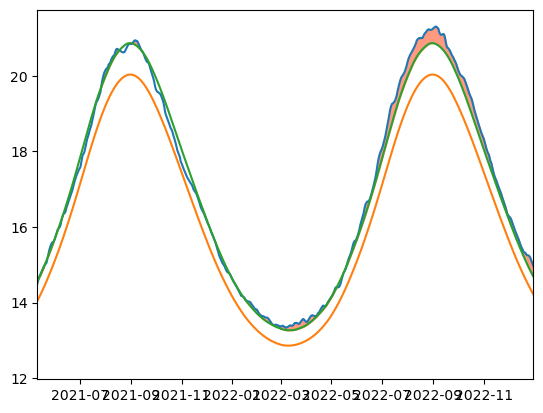

In [130]:
plt.plot(time_mhw,sst)
plt.plot(time_mhw,np.array(clim['seas']))
plt.plot(time_mhw,np.array(clim['thresh']))
plt.xlim(time_mhw[-600],time_mhw[-1])
ev = np.argmax(mhws['intensity_max']) # Find largest event
for ev0 in range(mhws['n_events']):
    t1 = np.where(t==mhws['time_start'][ev0])[0][0]
    t2 = np.where(t==mhws['time_end'][ev0])[0][0]
    plt.fill_between(time_mhw[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                     color=(1,0.6,0.5))

In [67]:
dataset=nc.Dataset(r'F:\OceanData\OISST_2022\oisst-avhrr-v02r01.20220101.nc')    # type: ignore
lons=np.array(dataset.variables['lon'])
lats=np.array(dataset.variables['lat'])
Lon,Lat=np.meshgrid(lons,lats)
# lat = slice(float(np.min(lats)),float(np.max(lats)+lats[1]-lats[0]), float(lats[1]-lats[0]))
# lon = slice(float(np.min(lons)),float(np.max(lons)+lons[1]-lons[0]), float(lons[1]-lons[0]))

In [74]:
lon_ind=(lons>=150)&(lons<=250)
lat_ind=(lats>=20)&(lats<=60)

In [83]:
def getfiles(filed):
    from os import listdir
    files=listdir(filed)
    files.sort()
    return [f'{filed}\\{i}' for i in files]
def readsst(fil):
    global lon_ind,lat_ind
    sst=np.array(nc.Dataset(fil)['sst'][0,:,:,:][:,:,lon_ind][:,lat_ind,:])
    sst[sst<-100]=np.nan
    return sst
ssts_2022=np.concatenate([readsst(fil) for fil in getfiles(r'F:\OceanData\OISST_2022')],axis=0)


In [84]:
a=np.swapaxes(ssts_2022,0,1)
a=np.swapaxes(a,1,2)
np.save('25_05_2023_oisstv2r01_NEP_2022.npy',a)

In [85]:
ssts_2021=np.load('25052023_oisstv2r01_NEP.npy')

In [87]:
np.save('25_05_2023_oisstv2r01_NEP.npy',np.concatenate([ssts_2021,a],axis=-1))


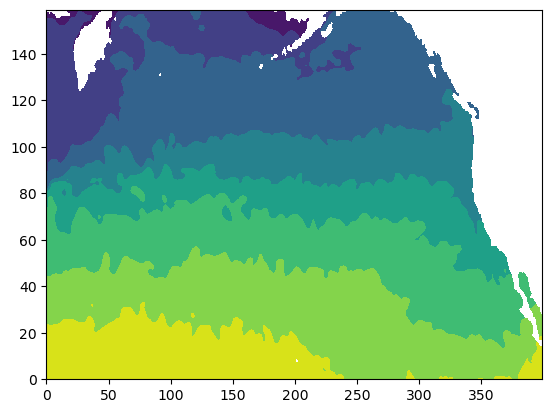

In [79]:
sst=np.array(dataset['sst'][0,0,:,:])
sst[sst<-100]=np.nan
plt.contourf(sst[:,lon_ind][lat_ind,:])

In [55]:
plot_sea_surface_temperature(-150, 250, 20, 60, '20210101', '20210131')

IndexError: boolean index did not match indexed array along dimension 1; dimension is 160 but corresponding boolean dimension is 159

In [30]:
start_date='20200101'
end_date='20200131'
time[(time>=pd.to_datetime(start_date))&(time<=pd.to_datetime(end_date))]

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
               '2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08',
               '2020-01-09', '2020-01-10', '2020-01-11', '2020-01-12',
               '2020-01-13', '2020-01-14', '2020-01-15', '2020-01-16',
               '2020-01-17', '2020-01-18', '2020-01-19', '2020-01-20',
               '2020-01-21', '2020-01-22', '2020-01-23', '2020-01-24',
               '2020-01-25', '2020-01-26', '2020-01-27', '2020-01-28',
               '2020-01-29', '2020-01-30', '2020-01-31'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
def app(left_longitude, right_longitude, top_latitude, bottom_latitude, time):

    # Create longitude and latitude ranges
    longitude_range = [left_longitude, right_longitude]
    latitude_range = [bottom_latitude, top_latitude]

    # Generate contour plot
    fig = generate_contour_plot(ds, longitude_range, latitude_range, time)

    return fig

# Define input fields
inputs = [gr.inputs.Slider(150, 250, step=0.5, label="Left Longitude"),
          gr.inputs.Slider(150, 250, step=0.5, label="Right Longitude"),
          gr.inputs.Slider(20, 60, step=0.5, label="Top Latitude"),
          gr.inputs.Slider20, 60, step=0.5, label="Bottom Latitude"),
          gr.inputs.Date(label="Date")]

# Define output field
output = gr.outputs.Image()

# Create interface
iface = gr.Interface(fn=app, inputs=inputs, outputs=output, title="Sea Surface Temperature Contour Plot")

# Launch interface
iface.launch()

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from cartopy import crs as ccrs


def plot_contours(left_lon, right_lon, top_lat, bottom_lat, start_date, end_date):

    # 读取数据
    ds = xr.open_dataset("https://www.ncei.noaa.gov/thredds/dodsC/OisstBase/NetCDF/V2.1/AVHRR/{year}/oisst-avhrr-v02r01.{year}{month:02}.nc").sel(lat=slice(bottom_lat, top_lat), lon=slice(left_lon, right_lon), time=slice(start_date, end_date))
    # 剖面和变量
    data = ds['sst']
    lats = data.coords['lat'].values
    lons = data.coords['lon'].values
    time = data.coords['time'].values

    # 绘制等高线图
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    levels = [-2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    norm = BoundaryNorm(levels, 256)

    plt.contourf(lons, lats, data[0], levels, cmap='coolwarm', norm=norm)
    plt.colorbar(label='Sea Surface Temperature (°C)')

    ax.coastlines()

    plt.title('Sea Surface Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    return fig


# 创建输入界面
inputs = [
           gr.inputs.Slider(20, 375, step=0.1, label="Left Longitude"),
           gr.inputs.Slider(20, 375, step=0.1, label="Right Longitude"),
           gr.inputs.Slider(-60, 60, step=0.1, label="Top Latitude"),
           gr.inputs.Slider(-60, 60, step=0.1, label="Bottom Latitude"),
           gr.inputs.Date(label="Start Date"),
           gr.inputs.Date(label="End Date"),
]

# 创建输出界面
output = gr.outputs.Figure()

# 创建Gradio应用
examples = [["-60", "60", "-30", "-50",  "2021-01-01", "2021-02-01"], ["20", "50", "10", "30", "2019-01-01", "2019-02-01"]]
gr.Interface(plot_contours, inputs, output, examples=examples,title="Ocean Surface Temperature Contour Map", description="An interactive map that shows the ocean surface temperature contour map.").launch()

In [8]:
import gradio as gr
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_sea_surface_temperature(left_lon, right_lon, lower_lat, upper_lat, start_date, end_date):
    # 下载海温数据
    url = 'https://psl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
    dataset = xr.open_dataset(url)

    # 数据缩放到指定矩形区域和时间范围
    sub_dataset = dataset.sel(
        time=slice(start_date, end_date),
        lon=slice(left_lon, right_lon),
        lat=slice(lower_lat, upper_lat),
    )

    # 计算区域平均海温
    mean_temperature = sub_dataset['sst'].mean(dim='time')

    # 创建带投影的地图图形
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    # 绘制等高线图
    cs = ax.contourf(
        mean_temperature['lon'],
        mean_temperature['lat'],
        mean_temperature,
        levels=np.arange(0, 28, 1),
        extend='both',
        transform=ccrs.PlateCarree(),
    )

    # 添加色标
    plt.colorbar(cs, label='海表温度（℃）', orientation='horizontal')

    # 保存图形为图片文件
    plt.savefig('sea_surface_temperature.png', dpi=100, bbox_inches='tight')

    # 返回图片路径供Gradio使用
    return 'sea_surface_temperature.png'

# 创建Gradio接口
iface = gr.Interface(
    fn=plot_sea_surface_temperature,
    inputs=[
        gr.inputs.Slider(-180, 180, 1, label='左经度'),
        gr.inputs.Slider(-180, 180, 1, label='右经度'),
        gr.inputs.Slider(-90, 90, 1, label='下纬度'),
        gr.inputs.Slider(-90, 90, 1, label='上纬度'),
        gr.inputs.Textbox(label="开始时间"),
        gr.inputs.Textbox(label="结束时间")
    ],
    outputs=gr.outputs.Image(type="filepath", label="海表温度等高图"),
    layout="vertical",
)
# 启动Gradio应用
iface.launch()

C:\Users\XUEX\AppData\Roaming\Python\Python310\site-packages\gradio\deprecation.py:40: UserWarning: `layout` parameter is deprecated, and it has no effect
  warnings.warn(value)
ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "C:\Users\XUEX\AppData\Roaming\Python\Python310\site-packages\gradio\routes.py", line 238, in main
  File "C:\Users\XUEX\AppData\Roaming\Python\Python310\site-packages\starlette\templating.py", line 112, in TemplateResponse
    template = self.get_template(name)
  File "C:\Users\XUEX\AppData\Roaming\Python\Python310\site-packages\starlette\templating.py", line 94, in get_template
    return self.env.get_template(name)
  File "c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\jinja2\environment.py", line 1010, in get_template
    return self._load_template(name, globals)
  File "c:\Users\XUEX\.conda\envs\pynb310\lib\site-packages\jinja2\environment.py", line 969, in _load_template
    template = self.loader.load(self, name, self.

ValueError: When localhost is not accessible, a shareable link must be created. Please set share=True.

In [6]:
dir(gr.inputs)

['Any',
 'Audio',
 'Checkbox',
 'CheckboxGroup',
 'Dataframe',
 'Dropdown',
 'File',
 'Image',
 'Image3D',
 'List',
 'Number',
 'Optional',
 'Radio',
 'Slider',
 'State',
 'Textbox',
 'Timeseries',
 'Tuple',
 'Video',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__warningregistry__',
 'annotations',
 'components',
 'warnings']